In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
df = pd.read_parquet("yellow_tripdata_2025-01.parquet")

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [5]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3475221,2,2025-01-31 23:01:48,2025-01-31 23:16:29,NaN,3.35,NaN,None,79,237,0,15.85,0.0,0.5,0.0,0.0,1.0,20.60,NaN,NaN,0.75
3475222,2,2025-01-31 23:50:29,2025-02-01 00:17:27,NaN,8.73,NaN,None,161,116,0,28.14,0.0,0.5,0.0,0.0,1.0,32.89,NaN,NaN,0.75
3475223,2,2025-01-31 23:26:59,2025-01-31 23:43:01,NaN,2.64,NaN,None,144,246,0,14.91,0.0,0.5,0.0,0.0,1.0,19.66,NaN,NaN,0.75
3475224,2,2025-01-31 23:14:34,2025-01-31 23:34:52,NaN,3.16,NaN,None,142,107,0,17.55,0.0,0.5,0.0,0.0,1.0,22.30,NaN,NaN,0.75
3475225,2,2025-01-31 23:56:42,2025-02-01 00:07:27,NaN,2.29,NaN,None,237,238,0,12.09,0.0,0.5,0.0,0.0,1.0,16.09,NaN,NaN,0.00


In [14]:
df.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2835217,2,2025-01-31 01:24:42,2025-01-31 01:36:44,1.0,2.65,1.0,N,137,262,1,14.2,1.0,0.5,3.99,0.0,1.0,23.94,2.5,0.0,0.75
1402229,2,2025-01-16 12:26:09,2025-01-16 12:31:18,1.0,0.94,1.0,N,141,262,1,7.2,0.0,0.5,2.80,0.0,1.0,14.00,2.5,0.0,0.00
2351319,2,2025-01-25 23:54:51,2025-01-26 00:09:38,2.0,1.85,1.0,N,50,229,2,14.9,1.0,0.5,0.00,0.0,1.0,20.65,2.5,0.0,0.75
1339372,2,2025-01-15 18:02:40,2025-01-15 18:10:17,1.0,1.18,1.0,N,211,79,1,9.3,2.5,0.5,3.16,0.0,1.0,19.71,2.5,0.0,0.75
2882037,2,2025-01-31 15:50:35,2025-01-31 16:17:08,2.0,6.11,1.0,N,261,100,1,31.7,0.0,0.5,5.47,0.0,1.0,41.92,2.5,0.0,0.75


In [15]:
df.shape

(3475226, 20)

In [16]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [17]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [19]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


In [18]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
dtype: int64

In [19]:
(df.isnull().mean()*100).sort_values(ascending=False)

VendorID                 0.0
tpep_pickup_datetime     0.0
Airport_fee              0.0
congestion_surcharge     0.0
total_amount             0.0
improvement_surcharge    0.0
tolls_amount             0.0
tip_amount               0.0
mta_tax                  0.0
extra                    0.0
fare_amount              0.0
payment_type             0.0
DOLocationID             0.0
PULocationID             0.0
store_and_fwd_flag       0.0
RatecodeID               0.0
trip_distance            0.0
passenger_count          0.0
tpep_dropoff_datetime    0.0
cbd_congestion_fee       0.0
dtype: float64

In [21]:
df.duplicated().sum()

0

In [8]:
df['passenger_count'] = (
    df['passenger_count']
    .fillna(df['passenger_count'].median())
)


In [11]:
df['RatecodeID'] = (
    df['RatecodeID']
    .fillna(df['RatecodeID'].mode()[0])
)

In [13]:
df['store_and_fwd_flag'] = (
    df['store_and_fwd_flag']
    .fillna('Unknown')
)

In [15]:
df['Airport_fee'] = (
    df['Airport_fee']
    .fillna(0)
)

In [17]:
df['congestion_surcharge'] = (
    df['congestion_surcharge']
    .fillna(0)
)

In [20]:
df.describe(include="all")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,3.475226e+06,3.475226e+06,3.475226e+06,3475226,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,2927431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.251563e+00,5.855126e+00,2.252106e+00,NaN,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,1.879372e+00,1.046518e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,NaN,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,NaN,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,NaN,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,NaN,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,NaN,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01


In [21]:
(df.isnull().mean()*100).sort_values(ascending=False)

VendorID                 0.0
tpep_pickup_datetime     0.0
Airport_fee              0.0
congestion_surcharge     0.0
total_amount             0.0
improvement_surcharge    0.0
tolls_amount             0.0
tip_amount               0.0
mta_tax                  0.0
extra                    0.0
fare_amount              0.0
payment_type             0.0
DOLocationID             0.0
PULocationID             0.0
store_and_fwd_flag       0.0
RatecodeID               0.0
trip_distance            0.0
passenger_count          0.0
tpep_dropoff_datetime    0.0
cbd_congestion_fee       0.0
dtype: float64

In [22]:
df[['passenger_count',
    'RatecodeID',
    'store_and_fwd_flag',
    'congestion_surcharge',
    'Airport_fee']].isna().sum()

passenger_count         0
RatecodeID              0
store_and_fwd_flag      0
congestion_surcharge    0
Airport_fee             0
dtype: int64

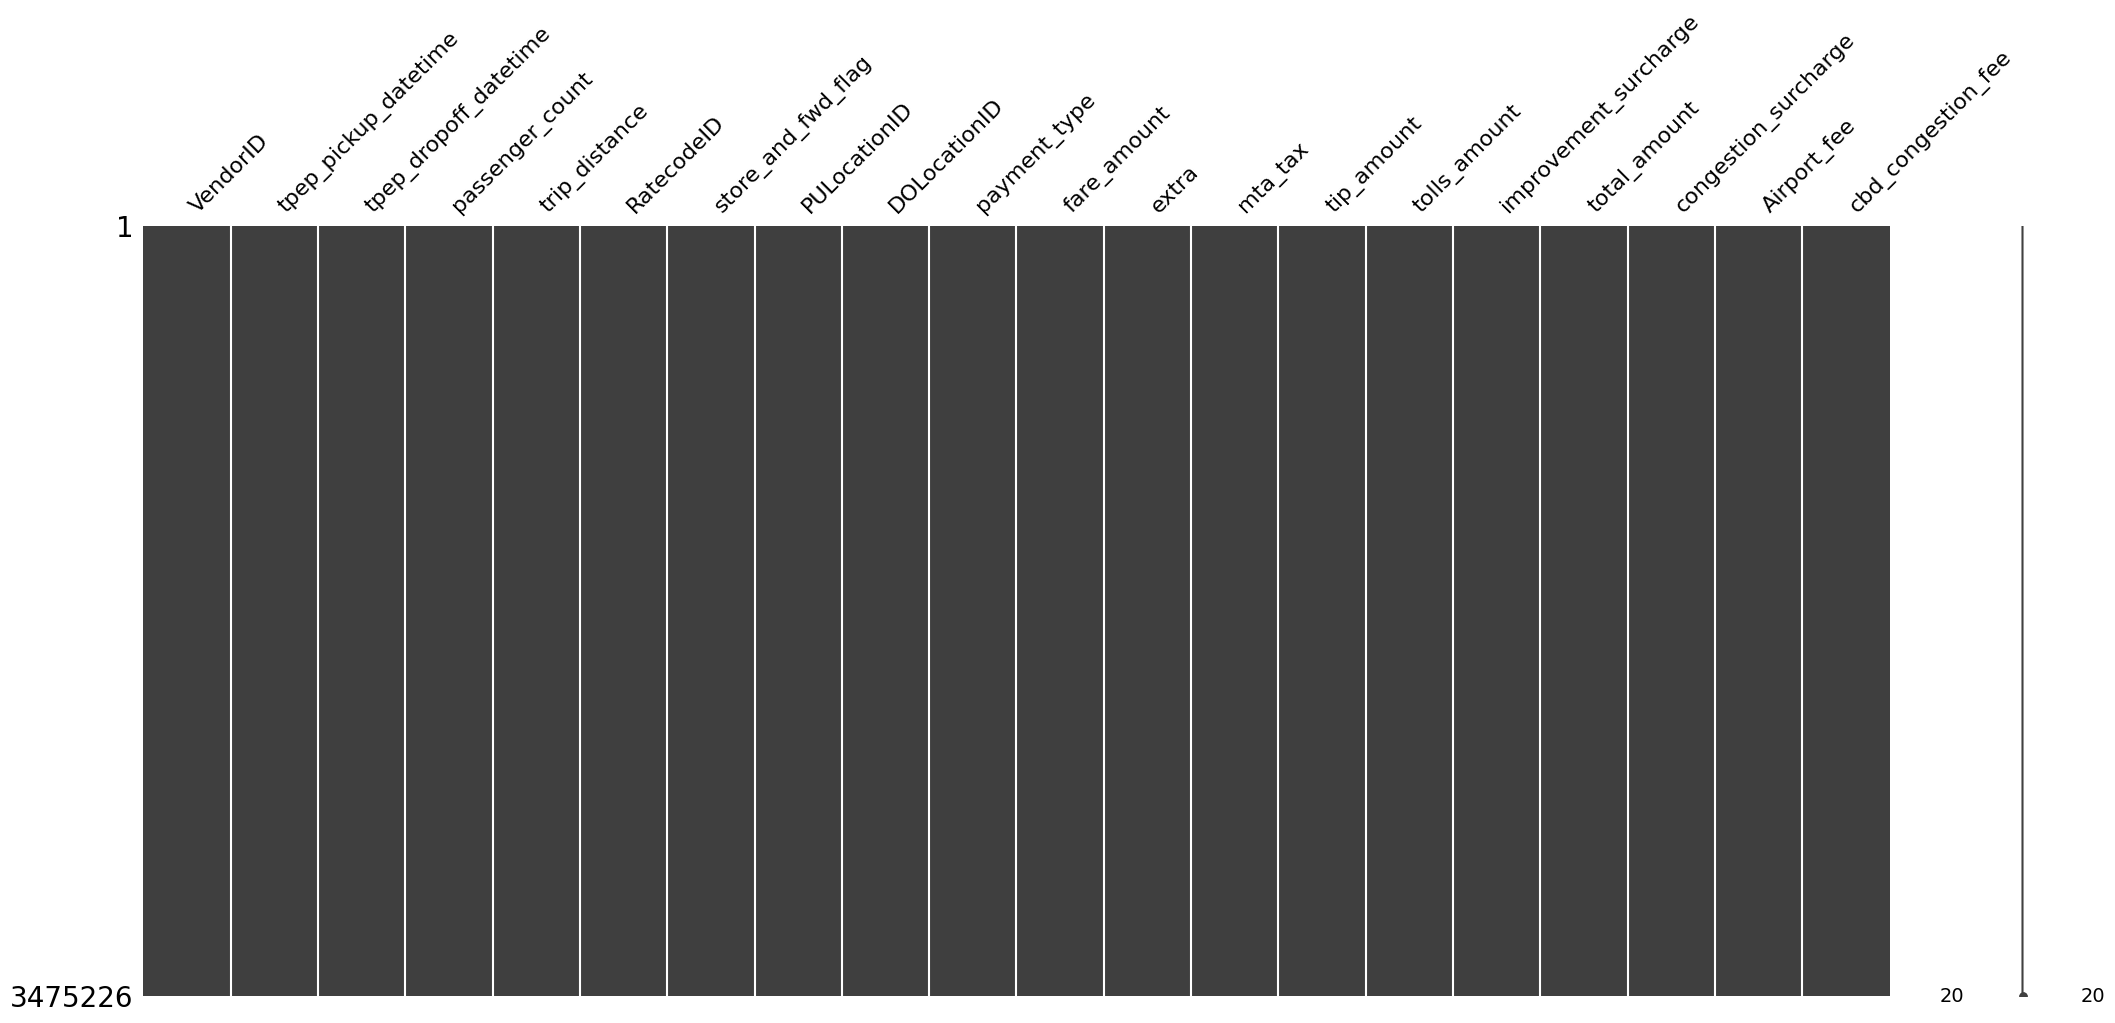

In [26]:
msno.matrix(df)
plt.show()

In [27]:
df.memory_usage(deep=True)

Index                          132
VendorID                  13900904
tpep_pickup_datetime      27801808
tpep_dropoff_datetime     27801808
passenger_count           27801808
trip_distance             27801808
RatecodeID                27801808
store_and_fwd_flag       204804002
PULocationID              13900904
DOLocationID              13900904
payment_type              27801808
fare_amount               27801808
extra                     27801808
mta_tax                   27801808
tip_amount                27801808
tolls_amount              27801808
improvement_surcharge     27801808
total_amount              27801808
congestion_surcharge      27801808
Airport_fee               27801808
cbd_congestion_fee        27801808
dtype: int64

In [28]:
df.memory_usage(deep=True).sum()/1024**2

659.3091716766357

In [29]:
df.nunique()

VendorID                       4
tpep_pickup_datetime     1672077
tpep_dropoff_datetime    1671993
passenger_count               10
trip_distance               4545
RatecodeID                     7
store_and_fwd_flag             3
PULocationID                 261
DOLocationID                 260
payment_type                   6
fare_amount                11538
extra                         77
mta_tax                        9
tip_amount                  4197
tolls_amount                1234
improvement_surcharge          4
total_amount               21995
congestion_surcharge           3
Airport_fee                    7
cbd_congestion_fee             3
dtype: int64

In [30]:
df["passenger_count"].value_counts()

passenger_count
1.0    2862583
2.0     407761
3.0      91409
4.0      59009
0.0      24656
5.0      17786
6.0      12004
8.0         11
7.0          4
9.0          3
Name: count, dtype: int64

In [4]:
df["payment_type"].value_counts()

payment_type
1    2444393
0     540149
2     390429
4      76481
3      23773
5          1
Name: count, dtype: int64

In [5]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

In [6]:
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [7]:
df["pickup_year"] = df["tpep_pickup_datetime"].dt.year

In [10]:
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

In [11]:
df["weekday"] = df["tpep_pickup_datetime"].dt.day_name()

In [12]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

In [13]:
df["is_weekend"] = df["weekday"].isin(["Saturday","Sunday"])

Trip Duration

In [14]:
df["trip_duration"] = (
    df["tpep_dropoff_datetime"]-
    df["tpep_pickup_datetime"]
).dt.total_seconds()/60

In [15]:
df["trip_duration"].describe()

count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
max      5.626317e+03
Name: trip_duration, dtype: float64

Distance Analysis

In [16]:
df["trip_distance"].mean()

5.855126178844196

In [17]:
df["trip_distance"].median()

1.67

In [18]:
df["trip_distance"].max()

276423.57

In [19]:
df["trip_distance"].min()

0.0

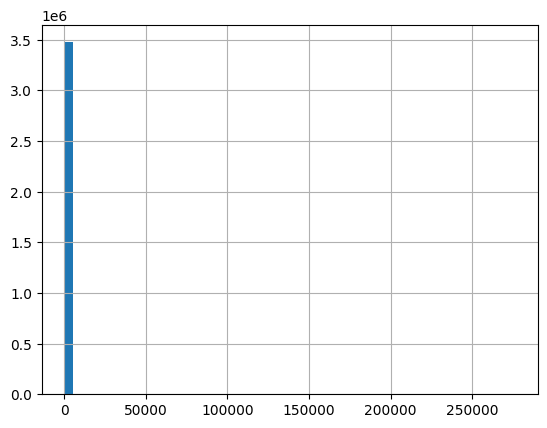

In [20]:
df["trip_distance"].hist(bins=50)
plt.show()

Fare Analysis

In [21]:
df["fare_amount"].mean()

17.081802760453577

In [22]:
df["fare_amount"].max()

863372.12

In [23]:
df["fare_amount"].min()

-900.0

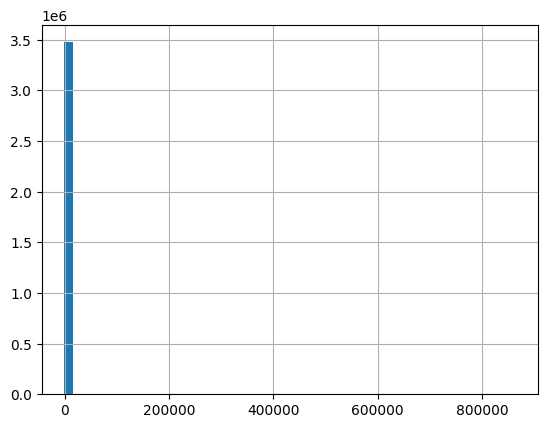

In [24]:
df["fare_amount"].hist(bins=50)
plt.show()

Total Amount Analysis

In [25]:
df["total_amount"].describe()

count    3.475226e+06
mean     2.561129e+01
std      4.636585e+02
min     -9.010000e+02
25%      1.520000e+01
50%      1.995000e+01
75%      2.778000e+01
max      8.633804e+05
Name: total_amount, dtype: float64

In [26]:
df.nlargest(10,"tip_amount")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,weekday,pickup_hour,is_weekend,trip_duration
1583318,2,2025-01-17 23:31:29,2025-01-18 00:12:47,1.0,14.74,1.0,N,232,216,1,...,473.15,2.5,0.0,0.75,2025,1,Friday,23,False,41.300000
2329131,2,2025-01-25 19:11:06,2025-01-25 19:11:10,1.0,0.00,1.0,N,216,216,1,...,364.50,0.0,0.0,0.00,2025,1,Saturday,19,True,0.066667
2329130,2,2025-01-25 19:07:42,2025-01-25 19:08:50,1.0,0.00,1.0,N,216,216,1,...,338.53,0.0,0.0,0.00,2025,1,Saturday,19,True,1.133333
286175,2,2025-01-04 15:41:54,2025-01-04 15:52:27,2.0,1.73,1.0,N,161,237,1,...,349.40,2.5,0.0,0.00,2025,1,Saturday,15,True,10.550000
2315999,2,2025-01-25 18:24:51,2025-01-25 18:48:28,1.0,2.69,1.0,N,79,164,1,...,328.95,2.5,0.0,0.75,2025,1,Saturday,18,True,23.616667
1184297,2,2025-01-14 11:17:31,2025-01-14 11:51:28,1.0,17.29,1.0,N,231,138,1,...,360.14,0.0,0.0,0.00,2025,1,Tuesday,11,False,33.950000
250630,2,2025-01-04 03:31:55,2025-01-04 03:51:06,2.0,9.83,1.0,N,161,138,1,...,317.34,2.5,0.0,0.00,2025,1,Saturday,3,True,19.183333
413087,1,2025-01-06 00:16:24,2025-01-06 00:31:03,1.0,3.00,1.0,N,264,212,1,...,250.30,0.0,0.0,0.00,2025,1,Monday,0,False,14.650000
1527704,1,2025-01-17 14:36:05,2025-01-17 14:44:04,1.0,1.40,1.0,N,263,229,1,...,239.80,2.5,0.0,0.75,2025,1,Friday,14,False,7.983333
2666918,2,2025-01-29 15:17:36,2025-01-29 15:28:22,1.0,1.11,1.0,N,237,162,1,...,235.45,2.5,0.0,0.75,2025,1,Wednesday,15,False,10.766667


Outlier Detection

In [28]:
Q1=df["trip_distance"].quantile(.25)
Q3=df["trip_distance"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df["trip_distance"]<lower)|(df["trip_distance"]>upper)]

In [29]:
len(outliers)

422436

Correlation

In [30]:
corr=df.corr(numeric_only=True)

corr

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,is_weekend,trip_duration
VendorID,1.000000,0.109692,0.002373,-0.213959,-0.006897,-0.005810,-0.004040,-0.001574,-0.532195,-0.064030,...,0.005708,-0.001300,0.010966,0.033776,0.024847,-0.001237,0.001242,0.031608,0.015869,-0.009063
passenger_count,0.109692,1.000000,0.003609,-0.045093,-0.010883,-0.006710,0.028031,0.001374,-0.065410,-0.030052,...,0.002661,0.001637,-0.001903,0.019702,-0.023705,-0.002162,0.002157,0.028323,0.075582,0.016918
trip_distance,0.002373,0.003609,1.000000,0.022977,-0.001946,-0.002209,-0.006932,0.000182,-0.002486,0.000327,...,0.000018,0.000201,-0.026774,0.060379,-0.000847,0.000010,-0.000010,-0.001475,-0.000148,0.002113
RatecodeID,-0.213959,-0.045093,0.022977,1.000000,-0.085538,-0.072965,-0.043661,0.004420,-0.098577,0.006502,...,-0.327924,0.002906,-0.303157,-0.022954,-0.157824,0.000330,-0.000331,-0.064143,-0.024244,0.089634
PULocationID,-0.006897,-0.010883,-0.001946,-0.085538,1.000000,0.086798,0.017246,-0.004137,-0.011122,0.017012,...,0.036775,-0.004792,0.118946,-0.143462,-0.076320,0.000729,-0.000738,0.021353,-0.030141,-0.034857
DOLocationID,-0.005810,-0.006710,-0.002209,-0.072965,0.086798,1.000000,0.015104,-0.004088,0.019548,0.023762,...,0.032639,-0.004276,0.111679,-0.044834,-0.055314,0.001612,-0.001620,0.024408,-0.025809,-0.029903
payment_type,-0.004040,0.028031,-0.006932,-0.043661,0.017246,0.015104,1.000000,-0.000650,0.097595,-0.424528,...,-0.412525,-0.002365,-0.418928,-0.026932,-0.159221,-0.000873,0.000872,-0.005044,-0.008429,-0.006559
fare_amount,-0.001574,0.001374,0.000182,0.004420,-0.004137,-0.004088,-0.000650,1.000000,0.007880,0.005531,...,0.008962,0.999913,-0.003113,0.023500,-0.000686,-0.000011,0.000011,-0.000642,-0.000626,0.007804
extra,-0.532195,-0.065410,-0.002486,-0.098577,-0.011122,0.019548,0.097595,0.007880,1.000000,0.160220,...,0.181917,0.013966,0.139416,0.311773,0.069912,0.000168,-0.000170,0.154107,-0.131228,0.021942
mta_tax,-0.064030,-0.030052,0.000327,0.006502,0.017012,0.023762,-0.424528,0.005531,0.160220,1.000000,...,0.856520,0.008489,0.697831,0.097272,0.203666,-0.000392,0.000393,0.006042,-0.008062,-0.001057


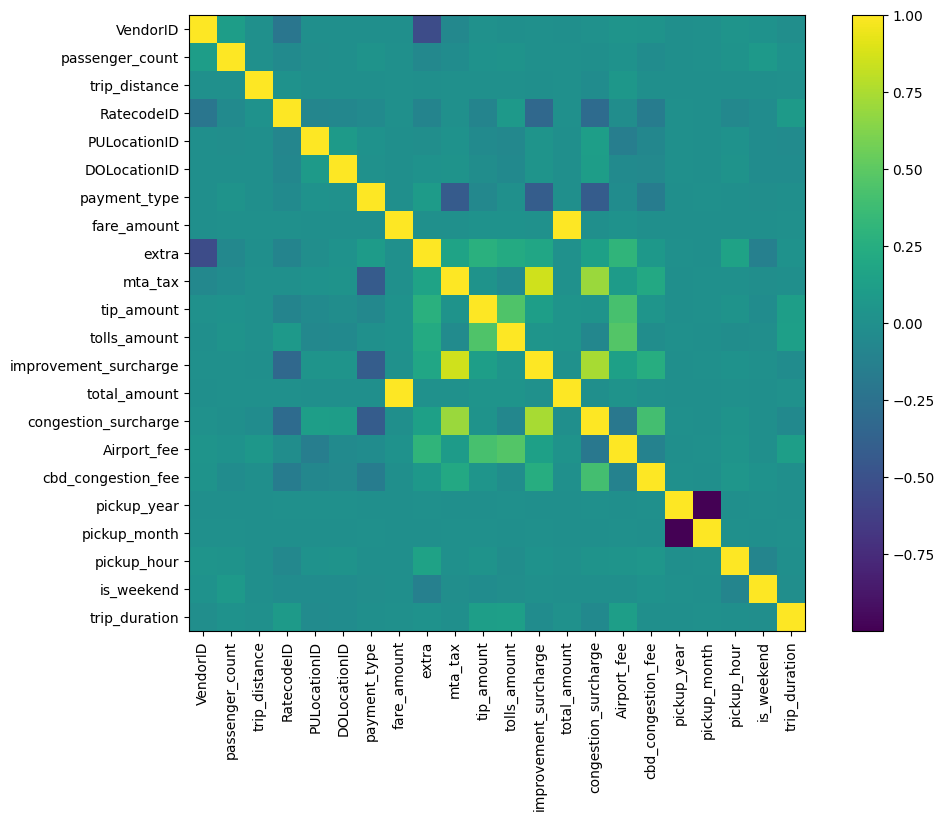

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.show()

GroupBy Questions

In [32]:
df.groupby("payment_type")["fare_amount"].mean()

payment_type
0    14.587529
1    18.008540
2    16.603058
3     4.498180
4    11.434029
5     0.000000
Name: fare_amount, dtype: float64

In [33]:
df.groupby("passenger_count")["trip_distance"].mean()

passenger_count
0.0     2.434000
1.0     3.094355
2.0     3.681512
3.0     3.483201
4.0     3.723703
5.0     2.938389
6.0     3.070723
7.0     0.005000
8.0     6.340000
9.0    14.863333
Name: trip_distance, dtype: float64

In [34]:
df.groupby("VendorID")["total_amount"].sum()

VendorID
1    20183067.41
2    68780553.52
6       14985.67
7       26420.20
Name: total_amount, dtype: float64

Sorting